Importing Required Packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
#from datasets import load_dataset

Importing Data


In [ ]:
#dataset = load_dataset("vinodcwanted/bank-customer-churn")
df = pd.read_csv('C:\PROJECTS\Customer Churn Bank\Dataset\Bank Customer Churn.csv')

In [4]:
print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())


Dataset Shape: (10000, 12)

First 5 rows of the dataset:
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


In [ ]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


Data Checks

In [6]:
df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

Handling Missing Values and Duplicates

In [8]:
df = df.drop_duplicates()
df = df.dropna()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [10]:
df.isna().sum()
df.duplicated().sum()

np.int64(0)

Unique Values

In [11]:
df.nunique()

customer_id         10000
credit_score          460
country                 3
gender                  2
age                    70
tenure                 11
balance              6382
products_number         4
credit_card             2
active_member           2
estimated_salary     9999
churn                   2
dtype: int64

In [12]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


EDA

In [ ]:
df = df.drop([ "customer_id"], axis = 1)

In [ ]:
print("Categories in 'Country' variable:     ",end = " " )
print(df['country'].unique())

print("Categories in 'Gender' variable:  ",end = " ")
print(df['gender'].unique())

Categories in 'Country' variable:      ['France' 'Spain' 'Germany']
Categories in 'Gender' variable:   ['Female' 'Male']


In [ ]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features : ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

We have 2 categorical features : ['country', 'gender']


Visualtization

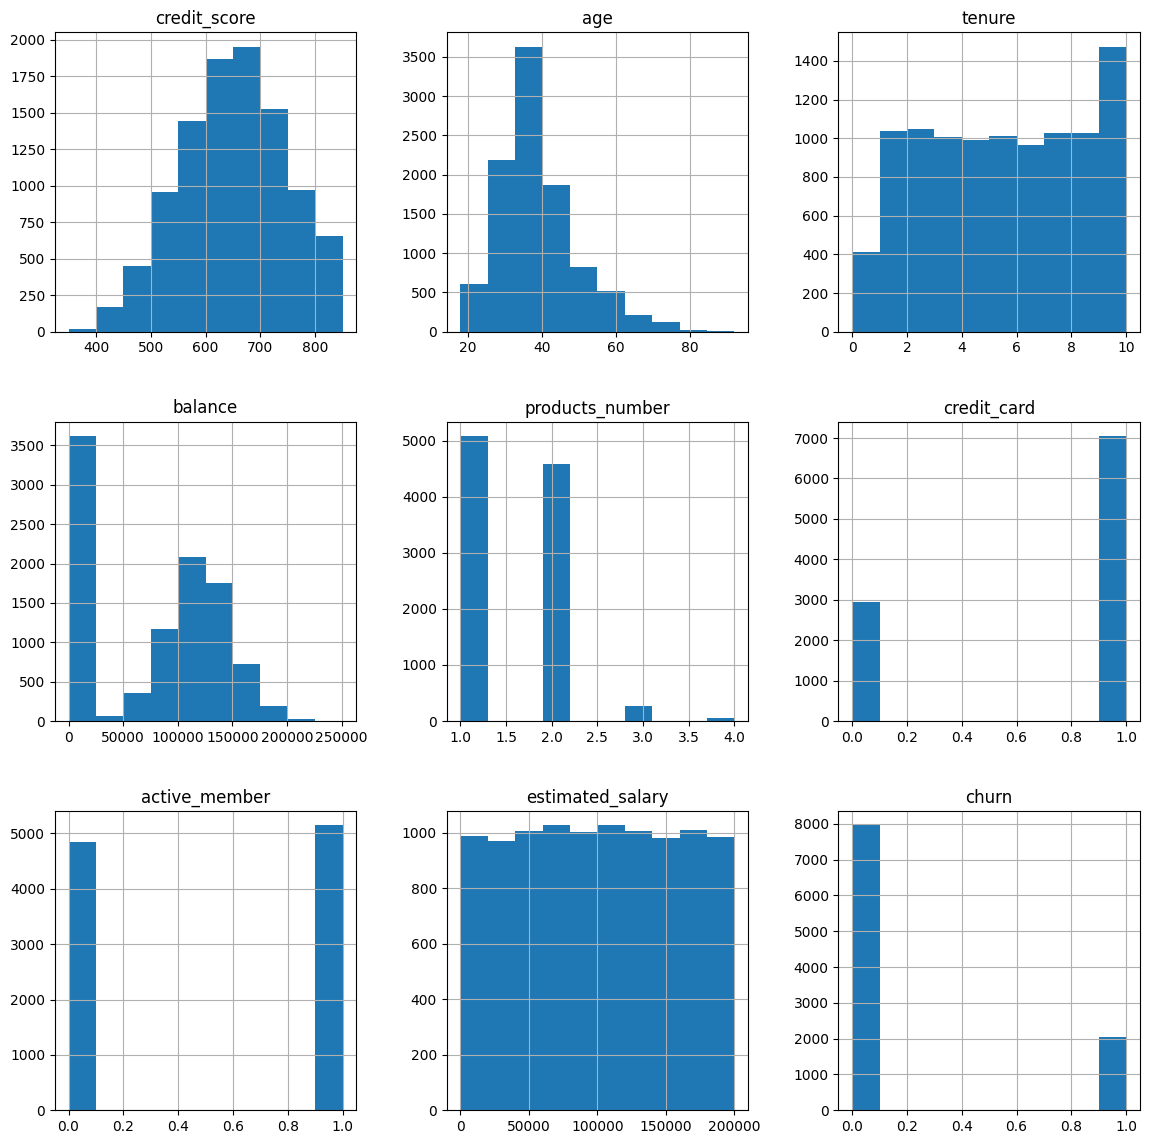

In [17]:
df.hist(figsize=(14,14))
plt.show()

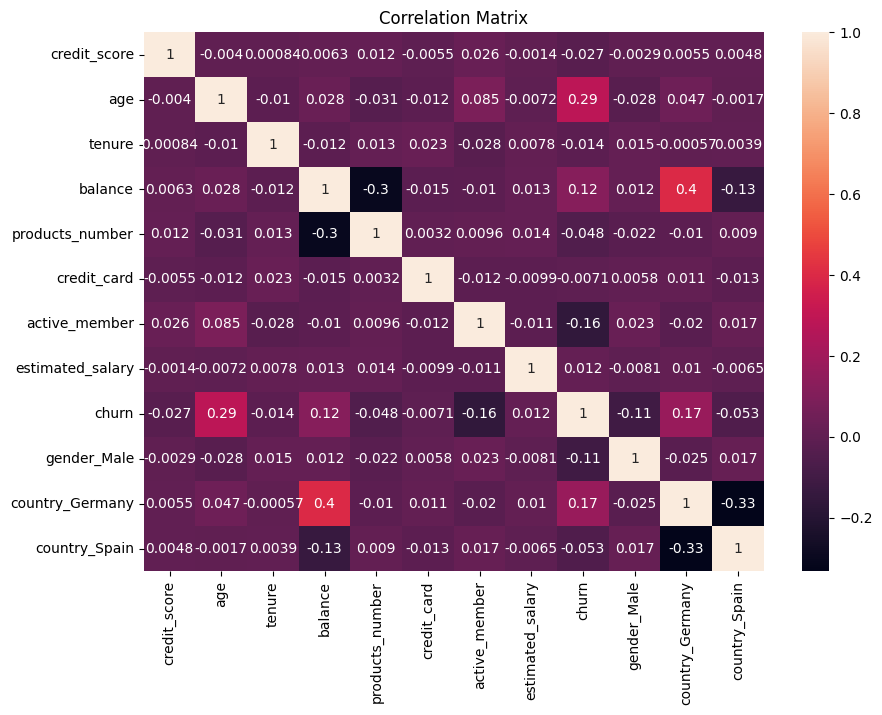

In [ ]:
# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=[ 'gender','country'], drop_first=True)

# Create a correlation matrix
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

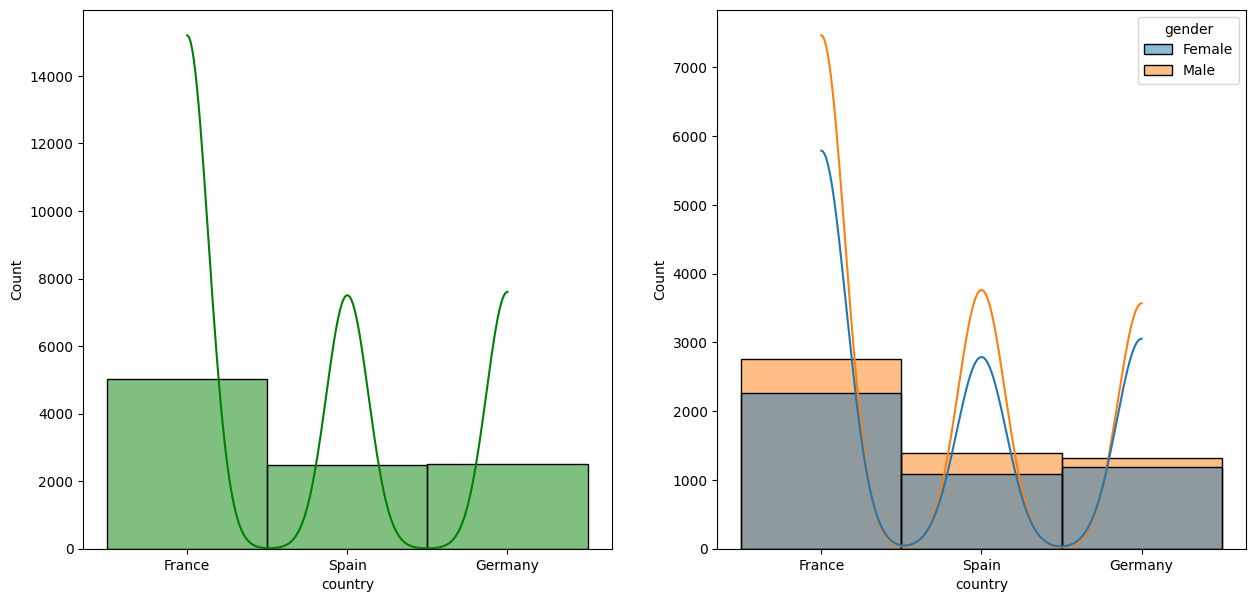

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='country',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='country',kde=True,hue='gender')
plt.show()

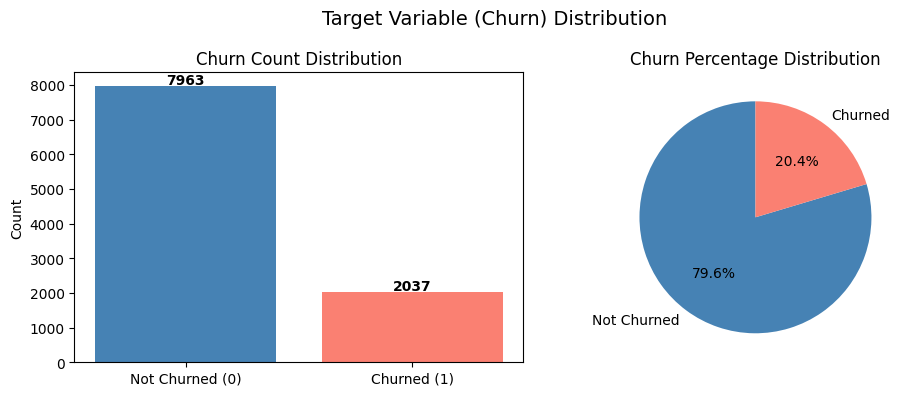

Churn rate: 20.4%


In [ ]:
# Target variable distribution - check for class imbalance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts = df['churn'].value_counts()

# Bar chart
axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Churn Count Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Churn Percentage Distribution')

plt.suptitle('Target Variable (Churn) Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Churn rate: {df['churn'].mean()*100:.1f}%")


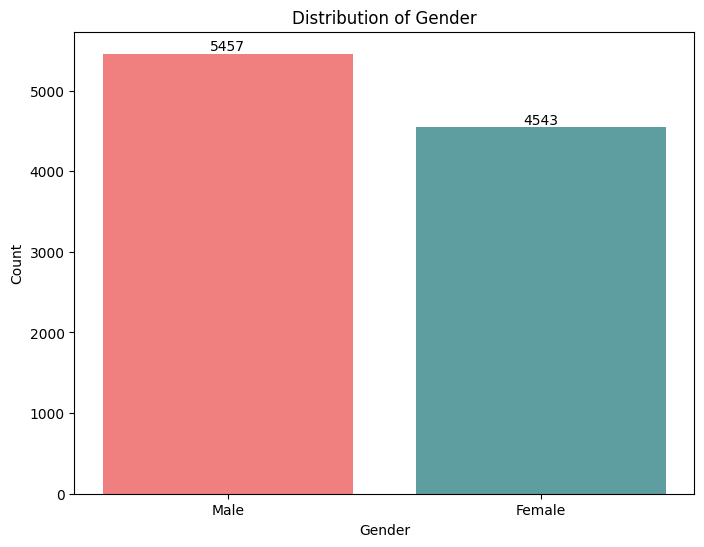

In [ ]:
plt.figure(figsize=(8,6))
label = ['Male', 'Female']
label = df['gender'].value_counts().index
colors = ['lightcoral', 'cadetblue'] 

plt.bar(label, df['gender'].value_counts().values, color=colors)

for i, count in enumerate(df['gender'].value_counts().values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.show()

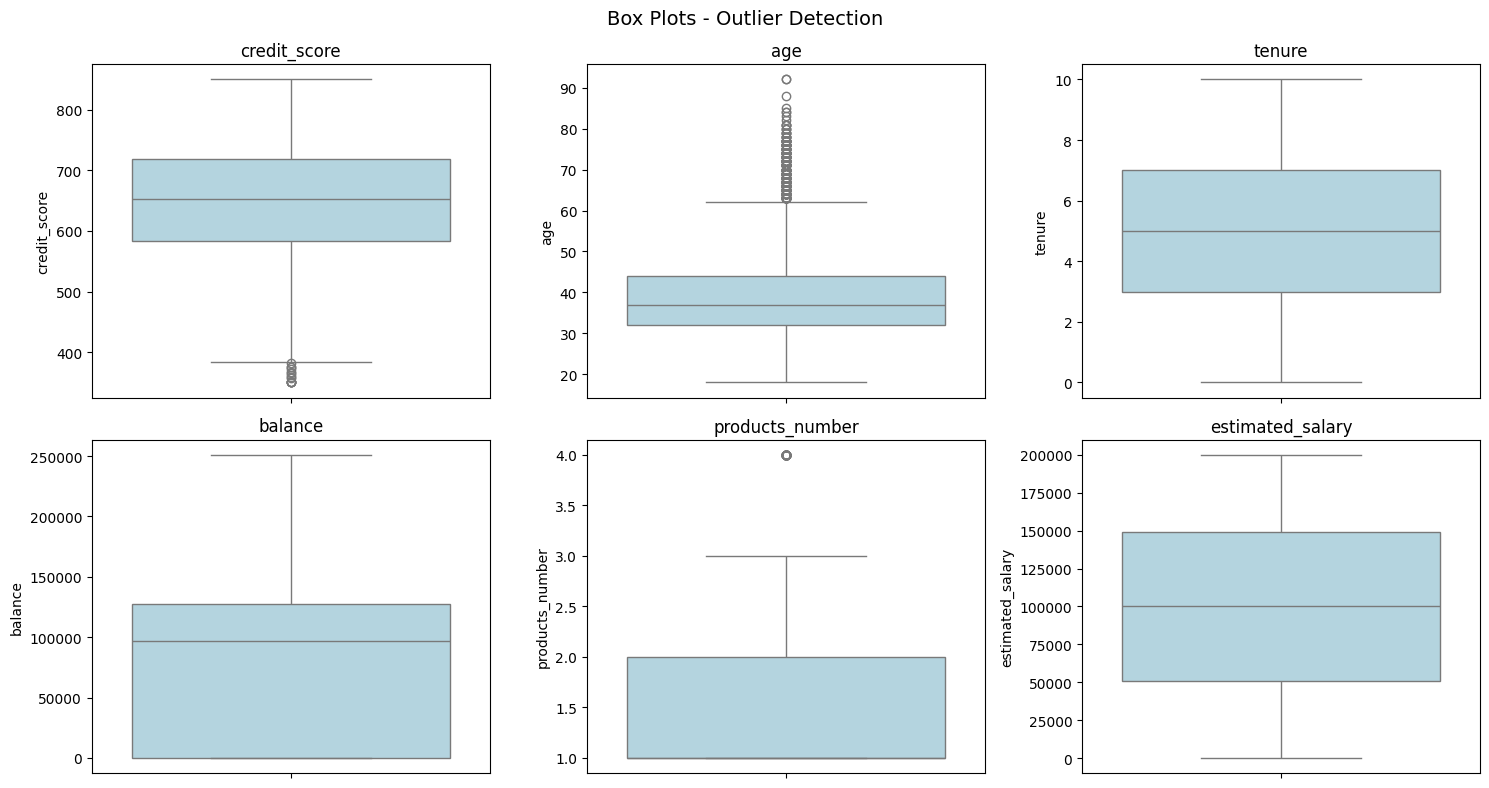

Outlier counts per feature (IQR method):
  credit_score: 15 outliers (0.1%)
  age: 359 outliers (3.6%)
  tenure: 0 outliers (0.0%)
  balance: 0 outliers (0.0%)
  products_number: 60 outliers (0.6%)
  estimated_salary: 0 outliers (0.0%)


In [ ]:
# Box plots 
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)

plt.suptitle('Box Plots - Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

# IQR-based outlier count
print("Outlier counts per feature (IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


In [ ]:
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.describe(include=['object'])

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


Churn Segmentation by Gender

In [ ]:
# Segmented "churn" by gender and displayed the frequency and percentage within each class
grouped = df.groupby('gender')['churn'].agg(Count='value_counts')
grouped

Count
gender churn       
Female 0       3404
       1       1139
Male   0       4559
       1        898

In [ ]:
dfgc = grouped
dfgc = dfgc.pivot_table(values='Count', index='gender', columns=['churn'])
dfgc

churn,0,1
gender,,
Female,3404.0,1139.0
Male,4559.0,898.0


In [ ]:
# Calculating percentage within each class
dfgp = grouped.groupby(level=[0]).apply(lambda g: round(g * 100 / g.sum(), 2))
dfgp.rename(columns={'Count': 'Percentage'}, inplace=True)
dfgp

Percentage
gender gender churn            
Female Female 0           74.93
              1           25.07
Male   Male   0           83.54
              1           16.46

In [27]:
# Reorganize dataframe for plotting percentage
dfgp = dfgp.pivot_table(values='Percentage', index='gender', columns=['churn'])
dfgp

churn,0,1
gender,,
Female,74.93,25.07
Male,83.54,16.46


Churn Segmentation by Geography

In [ ]:
# Segmented "churn" by country and displayed the frequency and percentage within each class
grouped = df.groupby('country')['churn'].agg(Count='value_counts')
grouped

Count
country churn       
France  0       4204
        1        810
Germany 0       1695
        1        814
Spain   0       2064
        1        413

In [ ]:
dfgeoc = grouped
dfgeoc = dfgeoc.pivot_table(values='Count', index='country', columns=['churn'])
dfgeoc

churn,0,1
country,,
France,4204.0,810.0
Germany,1695.0,814.0
Spain,2064.0,413.0


In [ ]:
# Calculating percentage within each class
dfgeop = grouped.groupby(level=[0]).apply(lambda g: round(g * 100 / g.sum(), 2))
dfgeop.rename(columns={'Count': 'Percentage'}, inplace=True)
dfgeop

Percentage
country country churn            
France  France  0           83.85
                1           16.15
Germany Germany 0           67.56
                1           32.44
Spain   Spain   0           83.33
                1           16.67

In [31]:
dfgeop = dfgeop.pivot_table(values='Percentage', index='country', columns=['churn'])
dfgeop

churn,0,1
country,,
France,83.85,16.15
Germany,67.56,32.44
Spain,83.33,16.67



Correlations

In [ ]:
# Converting Gender to numbers 
if 'gender' in df.columns and df['gender'].dtype == 'object':
    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# One-Hot Encoding on country (Turns 'France', 'Spain' into binary columns)
df = pd.get_dummies(df, columns=['country'])

In [ ]:
# Calculate correlations between numeric features
correlations = df.corr()

# sort features in order of their correlation with "churn"
sort_corr_cols = correlations.churn.sort_values(ascending=False).keys()
sort_corr = correlations.loc[sort_corr_cols,sort_corr_cols]
sort_corr

,churn,age,country_Germany,balance,estimated_salary,credit_card,tenure,credit_score,products_number,country_Spain,country_France,gender,active_member
churn,1.000000,0.285323,0.173488,0.118533,0.012097,-0.007138,-0.014001,-0.027094,-0.047820,-0.052667,-0.104955,-0.106512,-0.156128
age,0.285323,1.000000,0.046897,0.028308,-0.007201,-0.011721,-0.009997,-0.003965,-0.030680,-0.001685,-0.039208,-0.027544,0.085472
country_Germany,0.173488,0.046897,1.000000,0.401110,0.010297,0.010577,-0.000567,0.005538,-0.010419,-0.332084,-0.580359,-0.024628,-0.020486
balance,0.118533,0.028308,0.401110,1.000000,0.012797,-0.014858,-0.012254,0.006268,-0.304180,-0.134892,-0.231329,0.012087,-0.010084
estimated_salary,0.012097,-0.007201,0.010297,0.012797,1.000000,-0.009933,0.007784,-0.001384,0.014204,-0.006482,-0.003332,-0.008112,-0.011421
credit_card,-0.007138,-0.011721,0.010577,-0.014858,-0.009933,1.000000,0.022583,-0.005458,0.003183,-0.013480,0.002467,0.005766,-0.011866
tenure,-0.014001,-0.009997,-0.000567,-0.012254,0.007784,0.022583,1.000000,0.000842,0.013444,0.003868,-0.002848,0.014733,-0.028362
credit_score,-0.027094,-0.003965,0.005538,0.006268,-0.001384,-0.005458,0.000842,1.000000,0.012238,0.004780,-0.008928,-0.002857,0.025651
products_number,-0.047820,-0.030680,-0.010419,-0.304180,0.014204,0.003183,0.013444,0.012238,1.000000,0.009039,0.001230,-0.021859,0.009612
country_Spain,-0.052667,-0.001685,-0.332084,-0.134892,-0.006482,-0.013480,0.003868,0.004780,0.009039,1.000000,-0.575418,0.016889,0.016732


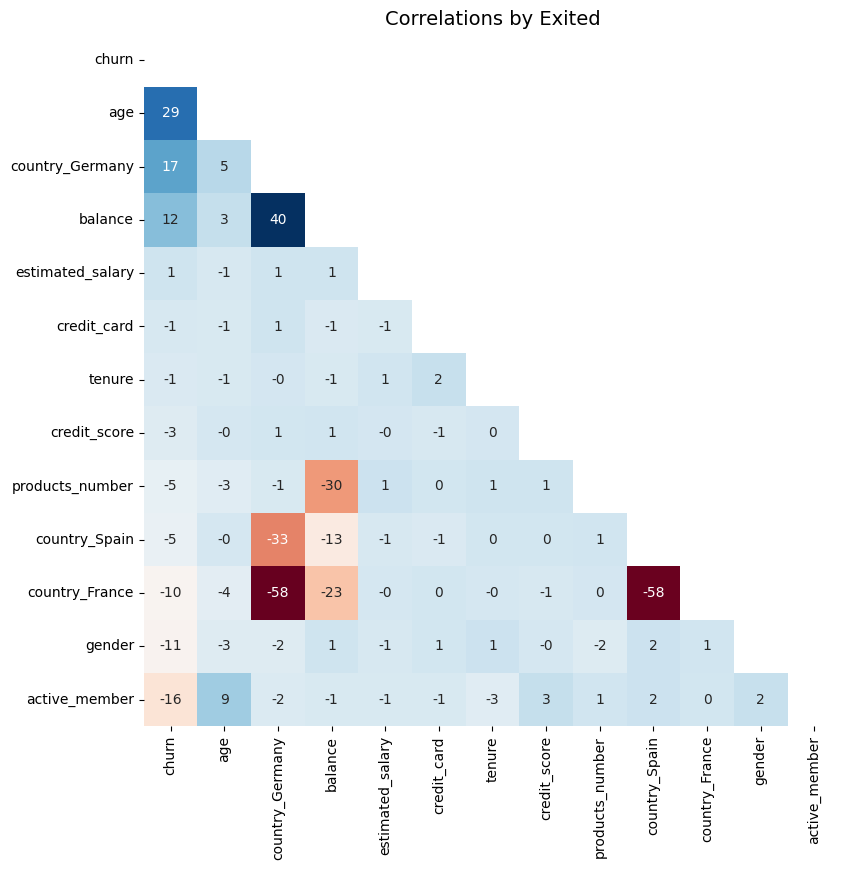

In [ ]:
corr_mask = np.zeros_like(correlations)
corr_mask[np.triu_indices_from(corr_mask)] = 1

plt.figure(figsize=(9,9))

# Plot heatmap of annotated correlations
sns.heatmap(sort_corr*100, 
                cmap='RdBu', 
                annot=True,
                fmt='.0f',
                mask=corr_mask,
                cbar=False)
    
plt.title('Correlations by Exited', fontsize=14)
plt.yticks(rotation=0)
plt.show()

Save the dataframe as the analytical base table

In [ ]:
df.to_csv('../Dataset/analytical_base_table.csv', index=False)